# 1. Phase explorations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # Added for custom legends
import scienceplots
import os

plt.style.use(["science","no-latex"])

## Columnar

### Vanilla Kuramoto - Edward-Wilkinson

In [30]:
typenoise = "Columnar"
L = 125
K = 40

deltaname = "0" # EW

path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"

df = pd.read_pickle(path)
df = df[(df["L"]==L) & (df["K"]==K)]
len(df)

3000

In [31]:
simulation = df.iloc[1]
t = simulation["t"]
phases = simulation["phases"]
R_EW = simulation["R"]

In [32]:
t, phases.shape

(array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
        4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
        2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
        1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
        1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
        7.55578378e+03, 1.20892560e+04, 1.93428197e+04]),
 (23, 125))

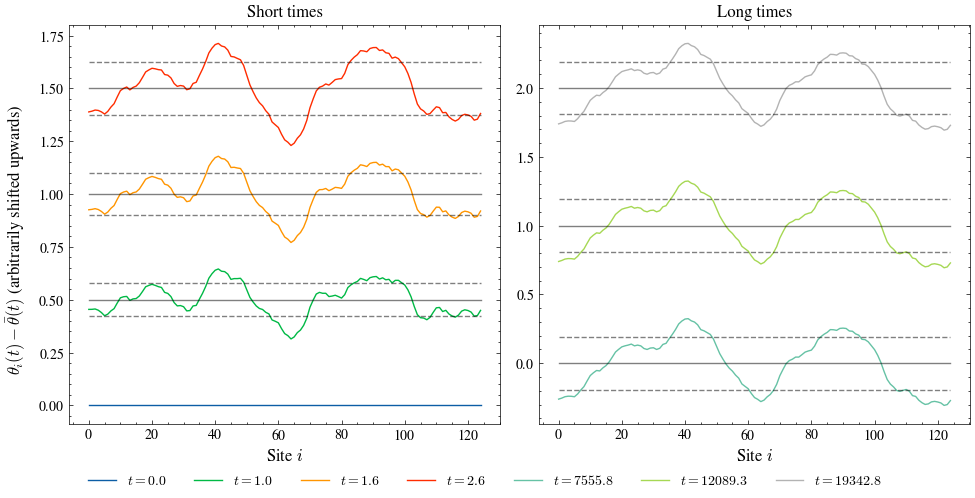

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
# fig.suptitle(r"Kuramoto-Sakaguchi ($\delta = 0$)")
fig.supylabel(r"$\theta_i(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")
ax[0].set_xlabel(r"Site $i$", fontsize=12)
ax[1].set_xlabel(r"Site $i$", fontsize=12)

ax[0].set_title("Short times")
for ti, displace in zip([0,1,2,3], [0,0.5,1,1.5]):
    ax[0].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[0].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[0].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[0].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

ax[1].set_title("Long times")
colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,1,2]), colors):
    ax[1].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), color=c, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[1].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[1].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[1].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

# one legend on the right (gather handles from both subplots)
h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax[1].get_legend_handles_labels()
fig.legend(h0 + h1, l0 + l1,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.02),   # push below the figure
           ncol=len(l0 + l1),             # or choose e.g. ncol=4
           frameon=False)

# leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.02, 1, 1])     # increase 0.08 if needed
plt.savefig("Figures/PhaseSnapshots/Columnar-Kuramoto.png", dpi=300)

### Kuramoto-Sakaguchi - KPZ

In [34]:
typenoise = "Columnar"
L = 125
K = 40

deltaname = "atan5" # EW

path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"

df = pd.read_pickle(path)
df = df[(df["L"]==L) & (df["K"]==K)]
len(df)

2999

In [38]:
simulation = df.iloc[2]
t = simulation["t"]
phases = simulation["phases"]
R_KPZ = simulation["R"]

In [39]:
t, phases.shape

(array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
        4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
        2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
        1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
        1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
        7.55578378e+03, 1.20892560e+04, 1.93428197e+04]),
 (23, 125))

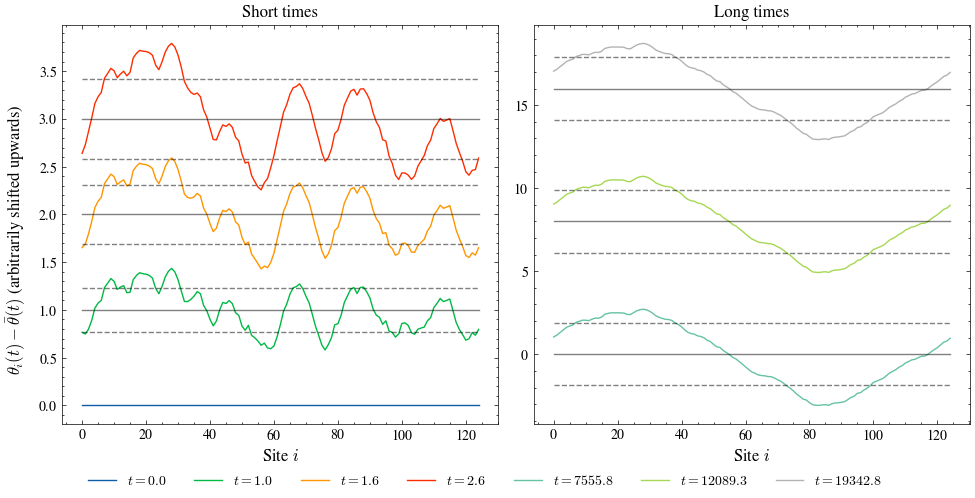

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
# fig.suptitle(r"Kuramoto-Sakaguchi ($\delta \neq 0$)")
fig.supylabel(r"$\theta_i(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")
ax[0].set_xlabel(r"Site $i$", fontsize=12)
ax[1].set_xlabel(r"Site $i$", fontsize=12)

ax[0].set_title("Short times")
for ti, displace in zip([0,1,2,3], [0,1,2,3]):
    ax[0].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[0].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[0].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[0].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

ax[1].set_title("Long times")
colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,8,16]), colors):
    ax[1].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), color=c, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[1].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[1].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[1].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

# one legend on the right (gather handles from both subplots)
h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax[1].get_legend_handles_labels()
fig.legend(h0 + h1, l0 + l1,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.02),   # push below the figure
           ncol=len(l0 + l1),             # or choose e.g. ncol=4
           frameon=False)

# leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.02, 1, 1])     # increase 0.08 if needed
# plt.savefig("Figures/PhaseSnapshots/Columnar-Sakaguchi.png", dpi=300)

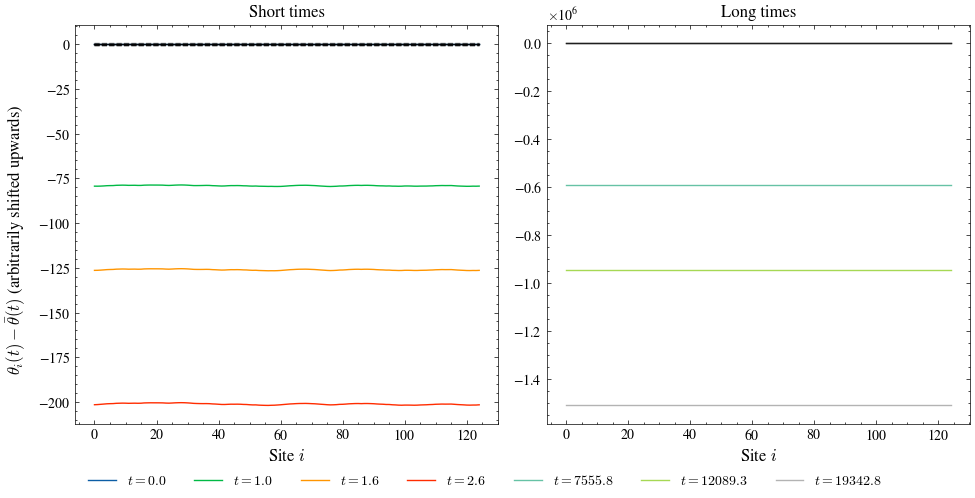

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
# fig.suptitle(r"Kuramoto-Sakaguchi ($\delta \neq 0$)")
fig.supylabel(r"$\theta_i(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")
ax[0].set_xlabel(r"Site $i$", fontsize=12)
ax[1].set_xlabel(r"Site $i$", fontsize=12)

ax[0].set_title("Short times")
for ti, displace in zip([0,1,2,3], [0,0,0,0]):
    ax[0].plot(range(L), phases[ti,:] + displace, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[0].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[0].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[0].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

ax[1].set_title("Long times")
colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,0,0]), colors):
    ax[1].plot(range(L), phases[ti,:] + displace, color=c, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[1].plot(range(L), L * [displace], color="k", alpha=0.5)

# one legend on the right (gather handles from both subplots)
h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax[1].get_legend_handles_labels()
fig.legend(h0 + h1, l0 + l1,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.02),   # push below the figure
           ncol=len(l0 + l1),             # or choose e.g. ncol=4
           frameon=False)

# leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.02, 1, 1])     # increase 0.08 if needed

## Time-dependent

### Vanilla Kuramoto - Edward-Wilkinson

In [10]:
typenoise = "TimeDep"
L = 125
K = 1

deltaname = "0" # EW

path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"

df = pd.read_pickle(path)
df = df[(df["L"]==L) & (df["K"]==K)]
len(df)

3000

In [11]:
simulation = df.iloc[1]
t = simulation["t"]
phases = simulation["phases"]
R_EW_t = simulation["R"]

In [12]:
t, phases.shape

(array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
        4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
        2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
        1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
        1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
        7.55578378e+03, 1.20892560e+04, 1.93428197e+04]),
 (23, 125))

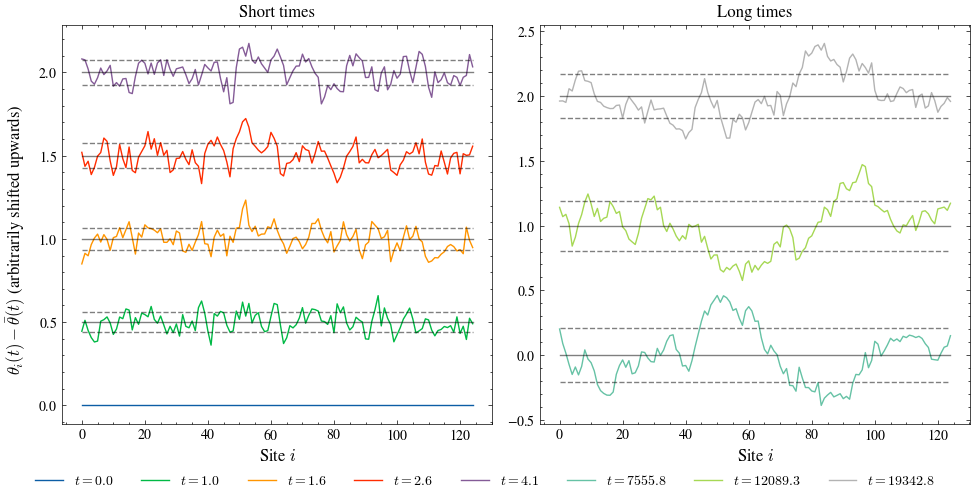

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
# fig.suptitle(r"Kuramoto-Sakaguchi ($\delta = 0$)")
fig.supylabel(r"$\theta_i(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")
ax[0].set_xlabel(r"Site $i$", fontsize=12)
ax[1].set_xlabel(r"Site $i$", fontsize=12)

ax[0].set_title("Short times")
for ti, displace in zip([0,1,2,3,4], [0,0.5,1,1.5,2]):
    ax[0].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[0].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[0].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[0].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

ax[1].set_title("Long times")
colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,1,2]), colors):
    ax[1].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), color=c, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[1].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[1].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[1].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

# one legend on the right (gather handles from both subplots)
h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax[1].get_legend_handles_labels()
fig.legend(h0 + h1, l0 + l1,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.02),   # push below the figure
           ncol=len(l0 + l1),             # or choose e.g. ncol=4
           frameon=False)

# leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.02, 1, 1])     # increase 0.08 if needed
plt.savefig("Figures/PhaseSnapshots/TimeDep-Kuramoto.png", dpi=300)

### Kuramoto-Sakaguchi - KPZ

In [14]:
typenoise = "TimeDep"
L = 125
K = 1

deltaname = "atan5" # EW

path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"

df = pd.read_pickle(path)
df = df[(df["L"]==L) & (df["K"]==K)]
len(df)

3000

In [15]:
simulation = df.iloc[1]
t = simulation["t"]
phases = simulation["phases"]
R_KPZ_t = simulation["R"]

In [16]:
t, phases.shape

(array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
        4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
        2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
        1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
        1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
        7.55578378e+03, 1.20892560e+04, 1.93428197e+04]),
 (23, 125))

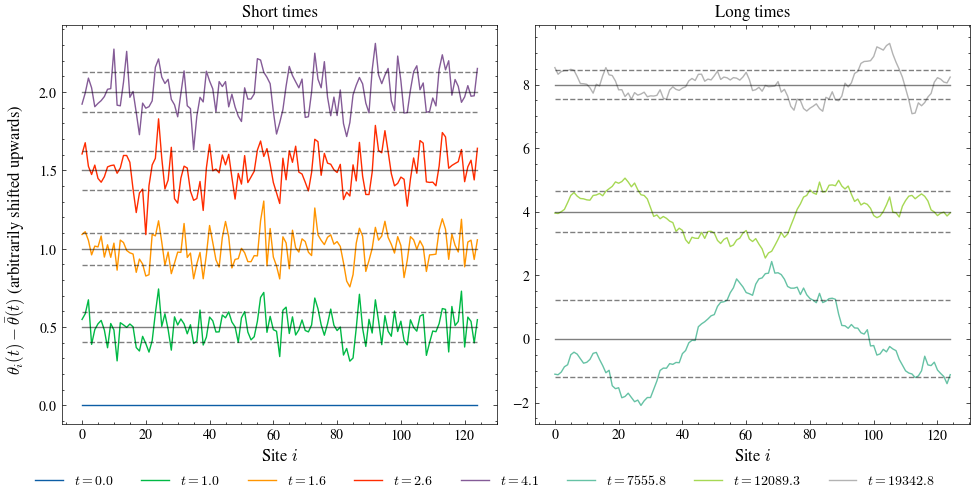

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))
# fig.suptitle(r"Kuramoto-Sakaguchi ($\delta \neq 0$)")
fig.supylabel(r"$\theta_i(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")
ax[0].set_xlabel(r"Site $i$", fontsize=12)
ax[1].set_xlabel(r"Site $i$", fontsize=12)

ax[0].set_title("Short times")
for ti, displace in zip([0,1,2,3,4], [0,0.5,1,1.5,2]):
    ax[0].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[0].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[0].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[0].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

ax[1].set_title("Long times")
colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,4,8]), colors):
    ax[1].plot(range(L), phases[ti,:] + displace - np.mean(phases[ti,:]), color=c, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[1].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[1].plot(range(L), L * [np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[1].plot(range(L), L * [-np.std(phases[ti,:]) + displace], color="k", linestyle="--", alpha=0.5)

# one legend on the right (gather handles from both subplots)
h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax[1].get_legend_handles_labels()
fig.legend(h0 + h1, l0 + l1,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.02),   # push below the figure
           ncol=len(l0 + l1),             # or choose e.g. ncol=4
           frameon=False)

# leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.02, 1, 1])     # increase 0.08 if needed
plt.savefig("Figures/PhaseSnapshots/TimeDep-Sakaguchi.png", dpi=300)

In [18]:
simulation

seed                                                       1003253
L                                                              125
K                                                              1.0
delta                                                     1.373401
T                                                            20000
Nt                                                         2000000
startsampling                                                  100
multsampling                                                   1.6
D                                                             0.01
omega            [-0.8586236066579651, -0.7412026694823857, -0....
t                [0.0, 1.00000050000025, 1.6000008000004002, 2....
phases           [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...
R                [1.0, 0.9953687050669292, 0.9947333109580071, ...
Psi              [0.0, -1.975412948592634, -3.141091823872332, ...
Name: L125_K1.0_seed1003253, dtype: object

## Order parameter

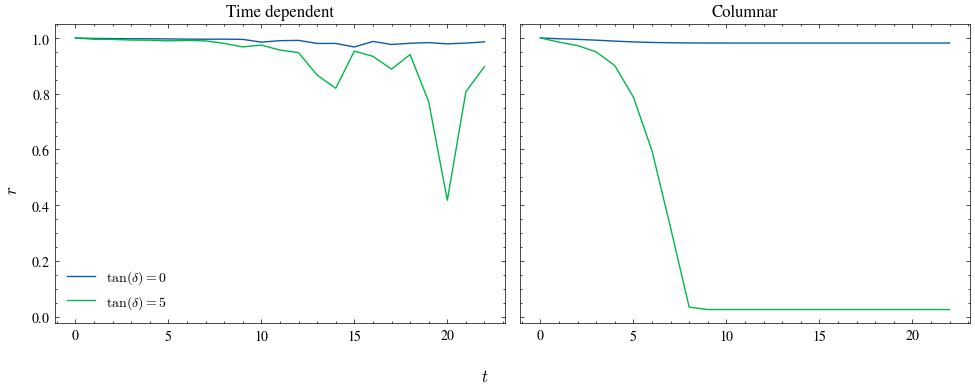

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(10,4), sharex=True, sharey=True)
ax[1].plot(R_EW, label=r"$\tan(\delta)=0$")
ax[1].plot(R_KPZ, label=r"$\tan(\delta)=5$")
ax[0].plot(R_EW_t, label=r"$\tan(\delta)=0$")
ax[0].plot(R_KPZ_t, label=r"$\tan(\delta)=5$")
ax[1].set_title("Columnar")
ax[0].set_title("Time dependent")

fig.supylabel("$r$")
fig.supxlabel("$t$")
# ax[1].legend()
ax[0].legend()
plt.tight_layout()

plt.savefig("Figures/TFM/orderparameter_columnar.png", dpi=300)

## Average phases and slopes

In [20]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        meanphase_list = []  # used to compute per-sim roughness
        meanslope_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            meanphase = np.mean(phases, axis=1)
            meanphase_list.append(meanphase)
            meanslope = np.mean(np.abs(phases-np.roll(phases,1,axis=1))**2, axis=1)
            meanslope_list.append(meanslope)

        # Avoid chained-assignment issues
        df = df.copy()
        df["meanphase"] = meanphase_list
        df["meanslope"] = meanslope_list

        ## AVERAGE ROUGHNESS PER (K, L, T) ##
        # group by K, L, T and compute mean roughness for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):

            meanphase_arrays = [np.asarray(r, dtype=float) for r in group["meanphase"]]
            mean_meanphase = np.mean(np.stack(meanphase_arrays, axis=0), axis=0)
            
            meanslope_arrays = [np.asarray(r, dtype=float) for r in group["meanslope"]]
            mean_meanslope = np.mean(np.stack(meanslope_arrays, axis=0), axis=0)
            
            # assume all t are identical within group; take the first
            t = group.iloc[0]["t"]
            seed_list = group.index.tolist()
            M = len(seed_list) 

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{M}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "typenoise": typenoise,
                    "delta": delta,
                    "deltaname": deltaname,
                    "K": K_val,
                    "L": L_val,
                    "t": t,
                    "M": M,
                    "T": T_val,
                    "mean_meanphase": mean_meanphase,
                    "mean_meanslope": mean_meanslope
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


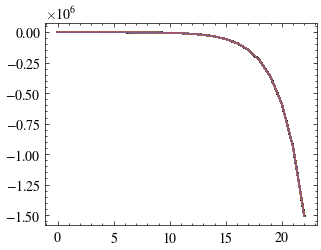

In [46]:
for arr in meanphase_arrays:
    plt.plot(arr)

In [21]:
mean_meanphase

array([ 0.00000000e+00, -7.91067858e+01, -1.26051184e+02, -2.01124978e+02,
       -3.20714444e+02, -5.12903157e+02, -8.19797338e+02, -1.31077827e+03,
       -2.09651354e+03, -3.35230839e+03, -5.36170503e+03, -8.57639636e+03,
       -1.37173713e+04, -2.19406325e+04, -3.50946780e+04, -5.61373985e+04,
       -8.97985958e+04, -1.43645393e+05, -2.29784802e+05, -3.67585507e+05,
       -5.88037295e+05, -9.40734043e+05, -1.50502978e+06])

In [22]:
# Note: we start from scratch the average DataFrame (each time this code is run)
avg_df = pd.DataFrame()
# avg_df_path = "../Simulations_1D/average_simulations.pkl"

# Build/update AverageSims dataframe
if summary_rows:
    new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
    if avg_df.empty:
        avg_df = new_avg
    else:
        # ensure we have an index; if not, give it one
        if avg_df.index.name is None:
            avg_df = avg_df.copy()
            avg_df.index.name = "avg_id"
        avg_df = pd.concat([avg_df, new_avg])
        # keep last occurrence per avg_id
        avg_df = avg_df[~avg_df.index.duplicated(keep="last")]

    # avg_df.to_pickle(avg_df_path)
    # print(f"Saved average simulations ({len(df)}) to:", avg_df_path)

In [23]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_meanphase,mean_meanslope
avg_id,,,,,,,,,,
TimeDep_delta0_L250_K0.01_T20000_M500,TimeDep,0.000000,0,0.01,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.00028746328517410195, 0.00045103135675...","[0.0, 0.019553142418484316, 0.0305884356535034..."
TimeDep_delta0_L125_K1.0_T20000_M3000,TimeDep,0.000000,0,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 0.00010313325531416978, 0.00014368697251...","[0.0, 0.004026835785073926, 0.0042653224812150..."
TimeDep_delta0_L250_K1.0_T20000_M3000,TimeDep,0.000000,0,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, -0.00018207046160059005, -7.770482341209...","[0.0, 0.004029964019393097, 0.0042602515171814..."
TimeDep_delta0_L500_K1.0_T20000_M3000,TimeDep,0.000000,0,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 3.446515215711387e-05, 0.000110998080832...","[0.0, 0.004022473642922749, 0.0042512926961454..."
TimeDep_delta0_L1000_K1.0_T20000_M5991,TimeDep,0.000000,0,1.00,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",5991,20000,"[0.0, -5.7422776114329244e-05, -6.753107581800...","[0.0, 0.004028800424337019, 0.0042608292981178..."
TimeDep_delta0_L10000_K1.0_T20000_M818,TimeDep,0.000000,0,1.00,10000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",818,20000,"[0.0, 3.7214111185997224e-05, 3.14817747968548...","[0.0, 0.004033502536571596, 0.0042586949231694..."
TimeDep_deltaatan5_L250_K0.01_T20000_M500,TimeDep,1.373401,atan5,0.01,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, -0.019958927884534457, -0.03145831768810...","[0.0, 0.020121844863349808, 0.0320438390712430..."
TimeDep_deltaatan5_L125_K1.0_T20000_M3000,TimeDep,1.373401,atan5,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, -1.9735887142205786, -3.142178048647658,...","[0.0, 0.012153331537169125, 0.0153141635078206..."
TimeDep_deltaatan5_L250_K1.0_T20000_M3000,TimeDep,1.373401,atan5,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, -1.9738999945161928, -3.1422818273989708...","[0.0, 0.012184465274553209, 0.0153594286212313..."


In [24]:
# Markers for different system sizes
markerdict = {125: "^", 250: "x", 500: "o", 1000: "s"}

colordict = {0: "tab:green", 1: "tab:blue"}

def plot_meanphase_evolution(avg_df, T, Ks=[1,40], save=False):

    fig, ax = plt.subplots(1, 4, figsize=(16,4))
    # fig.suptitle("Roughness evolution under different noise types")

    fig.supxlabel(r"$\log t$")
    fig.supylabel(r"$\langle\Delta\theta(L,t)\rangle$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
    ):
        print("#", typenoise)
        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            print("##", deltaname)
            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["deltaname"] == deltaname)
                & (avg_df["T"] == T)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
                & (avg_df["L"] < 10000)
            )
            sub_df = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub_df.iterrows():
                t = row["t"]
                mean_meanphase = row["mean_meanphase"]
                L = row["L"]
                K = row["K"]

                ax[i+2*j].scatter(t, mean_meanphase, label=r"$L=$" + str(L), marker=markerdict[L])

            ax[i+2*j].set_xscale('log')
            
            # ax[j,i].set_yscale('log')

            ax[i+2*j].set_title(fr"{typenoise}, $\delta=${deltaname}")
    # ax[0,1].set_title(f"Columnar ($K=${Ks[1]})")      
    # ax[0,0].set_ylabel(r"EW  ($\delta=0$)", fontsize=12)
    # ax[1,0].set_ylabel(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

    ax[2].set_xlim(1,1e5)
    ax[3].set_xlim(1,1e5)
    # ax[0].legend()
    # ax[1].legend()
    # ax[2].legend()
    ax[3].legend()

    plt.tight_layout()
    if save:
        plt.savefig("Figures/TFM/MeanPhases.png", dpi=300)
    plt.show()


def plot_meanphase_evolution_v2(avg_df, T, Ks=[1,40], save=False):

    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    # fig.suptitle("Roughness evolution under different noise types")

    fig.supxlabel(r"$\log t$")
    fig.supylabel(r"$\overline{\langle\theta(L,t)\rangle}$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
    ):
        print("#", typenoise)
        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            print("##", deltaname)
            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["deltaname"] == deltaname)
                & (avg_df["T"] == T)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
                & (avg_df["L"] < 10000)
            )
            sub_df = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub_df.iterrows():
                t = row["t"]
                mean_meanphase = row["mean_meanphase"]
                L = row["L"]
                K = row["K"]

                ax[i].scatter(t, mean_meanphase, label=r"$L=$" + str(L),
                              marker=markerdict[L], color=colordict[j])

            ax[i].set_xscale('log')
            
            # ax[i].set_yscale('log')

            ax[i].set_title(fr"{typelabel}")#, $\delta=${deltaname}")
            
    # --- MINIMAL MODIFICATION: Custom Legends ---
    
    # 1. Legend for L (Markers) on ax[0]
    # We use a neutral color like 'gray' to just highlight the shape
    handles_L = [Line2D([0], [0], marker=m, color='gray', linestyle='None', label=fr"$L={L}$") 
                 for L, m in markerdict.items()]
    ax[0].legend(handles=handles_L)

    # 2. Legend for deltaname (Colors) on ax[1]
    # We use a standard marker like 'o' to just highlight the color
    deltas = ["0", "atan5"]
    handles_delta = [Line2D([0], [0], marker='o', color=colordict[j], linestyle='None', label=fr"$\delta=${d}") 
                     for j, d in enumerate(deltas)]
    ax[1].legend(handles=handles_delta)

    # --------------------------------------------

    plt.tight_layout()
    if save:
        plt.savefig("Figures/TFM/MeanPhases.png", dpi=300)
    plt.show()


def plot_meanslope_evolution(avg_df, T, Ks=[1,40], save=False):

    fig, ax = plt.subplots(1, 4, figsize=(16,4))
    # fig.suptitle("Roughness evolution under different noise types")

    fig.supxlabel(r"$\log t$")
    fig.supylabel(r"$\langle\Delta\theta(L,t)\rangle$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
    ):
        print("#", typenoise)
        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            print("##", deltaname)
            # select rows for this noise type and delta
            mask = mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["deltaname"] == deltaname)
                & (avg_df["T"] == T)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
                & (avg_df["L"] < 10000)
            )
            sub_df = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub_df.iterrows():
                t = row["t"]
                mean_meanslope = row["mean_meanslope"]
                L = row["L"]
                K = row["K"]

                ax[i+2*j].scatter(t, mean_meanslope, label=r"$L=$" + str(L), marker=markerdict[L])

            ax[i+2*j].set_xscale('log')
            
            ax[i+2*j].set_yscale('log')

            # ax[i+2*j].set_title(fr"{typenoise}, $\delta=${deltaname}")
    # ax[0,1].set_title(f"Columnar ($K=${Ks[1]})")      
    # ax[0,0].set_ylabel(r"EW  ($\delta=0$)", fontsize=12)
    # ax[1,0].set_ylabel(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

    # ax[2].set_xlim(1,1e5)
    # ax[3].set_xlim(1,1e5)
    # ax[0].legend()
    # ax[1].legend()
    # ax[2].legend()
    ax[3].legend()

    plt.tight_layout()
    if save:
        plt.savefig("Figures/TFM/MeanSquSlopes.png", dpi=300)
    plt.show()

# TimeDep
## 0
## atan5
# Columnar
## 0
## atan5


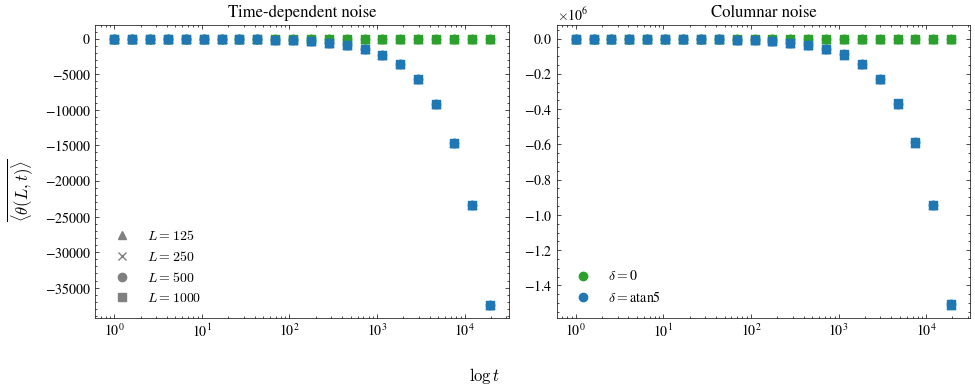

In [25]:
plot_meanphase_evolution_v2(avg_df, T = 20000, Ks = [1, 40], save=True)

# TimeDep
## 0
## atan5
# Columnar
## 0
## atan5


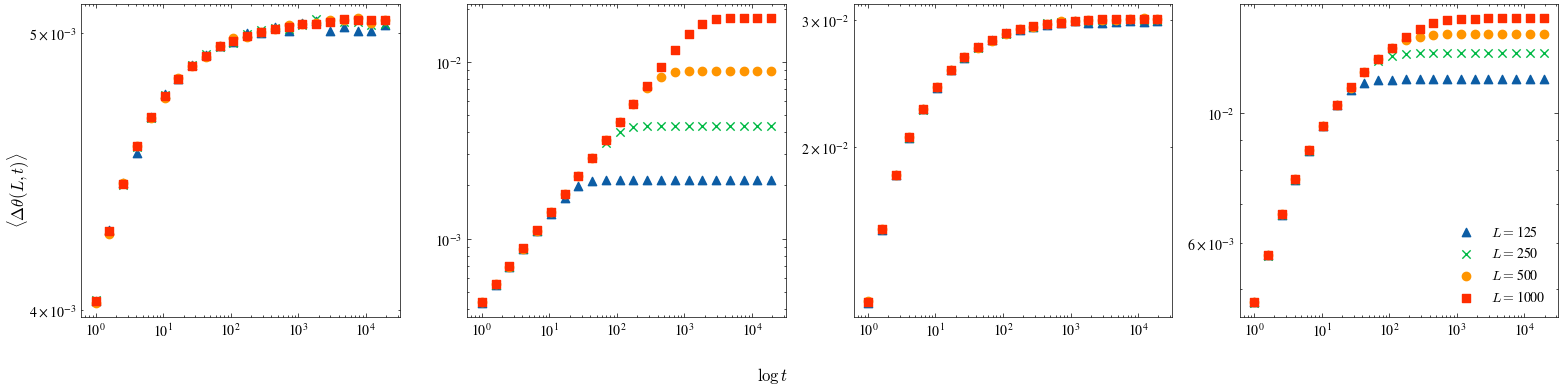

In [26]:
plot_meanslope_evolution(avg_df, T = 20000, Ks = [1, 40])

In [27]:
# --- SWAPPED DICTIONARIES ---
# Colors for different system sizes (L)
colordict_L = {125: "tab:blue", 250: "tab:orange", 500: "tab:green", 1000: "tab:red"}

# Markers for different deltas (using the enumerate index j: 0 or 1)
markerdict_delta = {0: "o", 1: "^"}

def plot_meanphase_evolution_v2(avg_df, T, Ks=[1,40], save=False):

    fig, ax = plt.subplots(1, 2, figsize=(10,4))

    fig.supxlabel(r"$\log t$")
    fig.supylabel(r"$\langle\Delta\theta(L,t)\rangle$")

    for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])):
        print("#", typenoise)
        for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

            print("##", deltaname)
            # select rows for this noise type and delta
            mask = (
                (avg_df["typenoise"] == typenoise)
                & (avg_df["deltaname"] == deltaname)
                & (avg_df["T"] == T)
                & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
                & (avg_df["L"] < 10000)
            )
            sub_df = avg_df[mask]

            # in case there are multiple (K, L) combos, plot them all
            for _, row in sub_df.iterrows():
                t = row["t"]
                mean_meanphase = row["mean_meanphase"]
                L = row["L"]
                K = row["K"]

                # SWAPPED: marker is now based on delta (j), color is based on L
                ax[i].scatter(t, mean_meanphase, marker=markerdict_delta[j], color=colordict_L[L], alpha=0.3)

            ax[i].set_xscale('log')
            ax[i].set_title(fr"{typelabel}")

    ax[1].set_xlim(1,1e5)

    # --- SWAPPED LEGENDS ---
    
    # 1. Legend for L (Colors) on ax[0]
    # We use a standard circular marker ('o') to show off the different colors for L
    handles_L = [Line2D([0], [0], marker='o', color=c, linestyle='None', label=fr"$L={L}$") 
                 for L, c in colordict_L.items()]
    ax[0].legend(handles=handles_L)

    # 2. Legend for deltaname (Markers) on ax[1]
    # We use a neutral color ('gray') to show off the different marker shapes for delta
    deltas = ["0", "atan5"]
    handles_delta = [Line2D([0], [0], marker=markerdict_delta[j], color='gray', linestyle='None', label=fr"$\delta=${d}") 
                     for j, d in enumerate(deltas)]
    ax[1].legend(handles=handles_delta)

    # --------------------------------------------

    plt.tight_layout()
    if save:
        plt.savefig("Figures/TFM/MeanPhases.png", dpi=300)
    plt.show()

# TimeDep
## 0
## atan5
# Columnar
## 0
## atan5


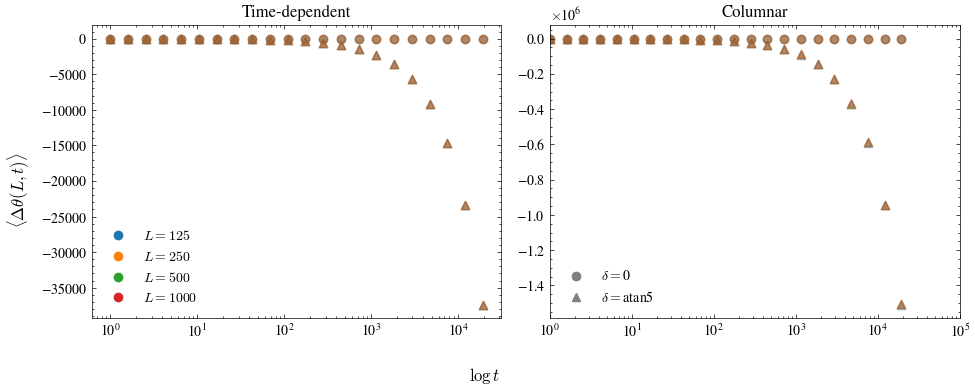

In [28]:
plot_meanphase_evolution_v2(avg_df, 20000, Ks=[1,40], save=False)